# Moat detection tuning playground

Cache reduced epochs once, then sweep the four `detect_moats` knobs
(`area_thresh_pix`, `radius_factor`, `shrink`, `overlap_shrink`) fast.
See `docs/superpowers/specs/2026-07-01-moat-tuning-design.md`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))  # run from repo root

import numpy as np
import matplotlib.pyplot as plt

from sdo_clv_pipeline.moat_cache import cache_epochs, cache_epoch, load_cached_epoch, default_cache_dir
import moat_tuning as mt

/mnt/home/mpalumbo/work/sdo-clv-pipeline/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cache epochs (once, slow: ~15-60 s each)

Pick epochs spanning disk position and clustered/isolated spots. Reruns are
cheap: existing cache files are skipped unless `clobber=True`.

In [2]:
fitsdir = "/mnt/ceph/users/mpalumbo/sdo_data/"
paths = cache_epochs(fitsdir, globexp="2014*01*07*")  # adjust glob per target
paths

[PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T00:00:00.npz'),
 PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T04:00:00.npz'),
 PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T08:00:00.npz'),
 PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T12:00:00.npz'),
 PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T16:00:00.npz'),
 PosixPath('/mnt/ceph/users/mpalumbo/sdo_data/moat_cache/moat_epoch_2014-01-07T20:00:00.npz')]

## 2. Run the kernel on a cached epoch

In [3]:
iso = load_cached_epoch(paths[0])["iso"]  # or paste an ISO timestamp
epoch, result = mt.run_on_cached(iso, radius_factor=1.2, shrink=0.97)
print(len(result.profiles), "spots,", int(result.moat_mask.sum()), "moat pixels")

12 spots, 131577 moat pixels


## 3. Tune by eye: overlay masks on continuum / velocity

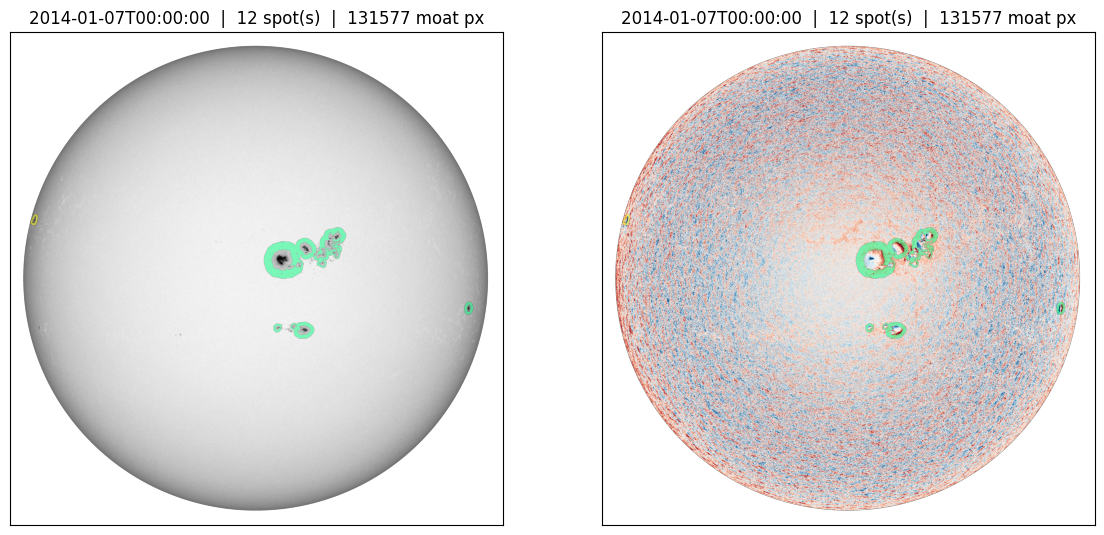

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
mt.overlay_moats(epoch, result, background="continuum", ax=axes[0])
mt.overlay_moats(epoch, result, background="v_corr", ax=axes[1])
plt.show()

## 4. Tune against the flow: radial profiles

Dashed lines mark each spot's current cutoff radius. Read off where the
velocity/field settles to decide the radius factor.

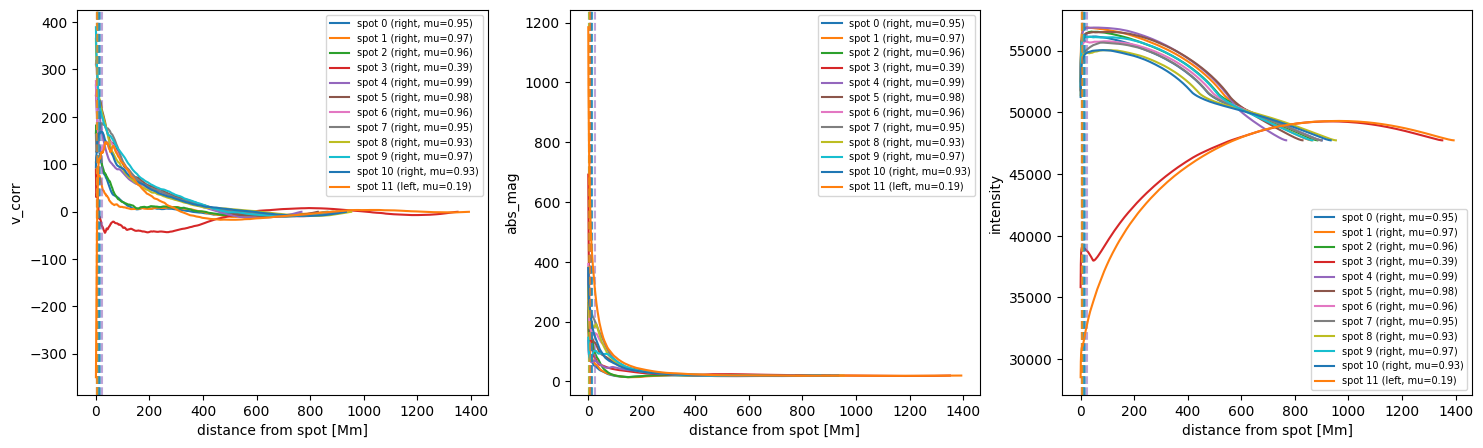

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mt.plot_profiles(result, quantity="v_corr", distance="Mm", ax=axes[0])
mt.plot_profiles(result, quantity="abs_mag", distance="Mm", ax=axes[1])
mt.plot_profiles(result, quantity="intensity", distance="Mm", ax=axes[2])
plt.show()

## 5. Sweep a knob side-by-side

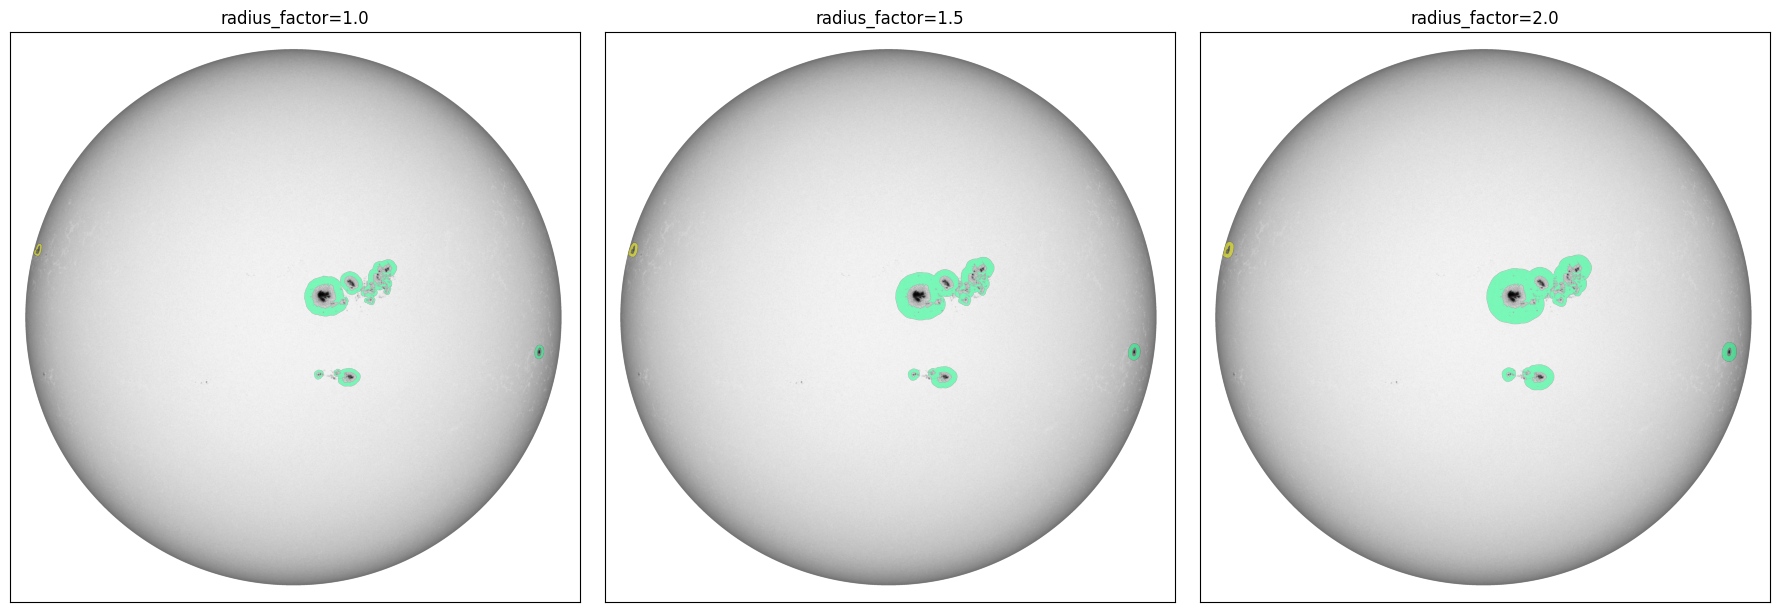

In [6]:
grid = [{"radius_factor": 1.0}, {"radius_factor": 1.5}, {"radius_factor": 2.0}]
swept = mt.compare_params(iso, grid, background="continuum")
plt.show()